In [186]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)
theme_set(
    theme_classic(base_size = 12)
)


## Figure1B

In [54]:
tpm<- read.table('../data/1_total_rna_rsem_iso_TPM.tsv')
tpm_ave<- cbind(data.frame(WT = rowSums(tpm[, c(1:3)])/3), data.frame(MUT = rowSums(tpm[, c(4:6)])/3))
final_iso_tb<- read.table('../data/2_final_iso_tb.tsv', header = T, row.names = 1, sep = '\t')
tpm_ave$class = final_iso_tb[match(rownames(tpm_ave), rownames(final_iso_tb)), 'class']
tpm_ave<- tpm_ave %>% filter(!is.na(class))
tpm_ave$class<- factor(tpm_ave$class, levels = c('low', 'medium', 'high'))

In [55]:
tpm_ave$class %>% table()

.
   low medium   high 
  1476   3538   1278 

Warning message in ggplot2::geom_density(colour = "NA", ...):
“Ignoring unknown parameters: `binwidth`”
Warning message in (function (mapping = NULL, data = NULL, stat = "identity", position = "identity", :
“Ignoring unknown parameters: `binwidth`”
Warning message in ggplot2::geom_density(colour = "NA", ...):
“Ignoring unknown parameters: `binwidth`”
Warning message in (function (mapping = NULL, data = NULL, stat = "identity", position = "identity", :
“Ignoring unknown parameters: `binwidth`”


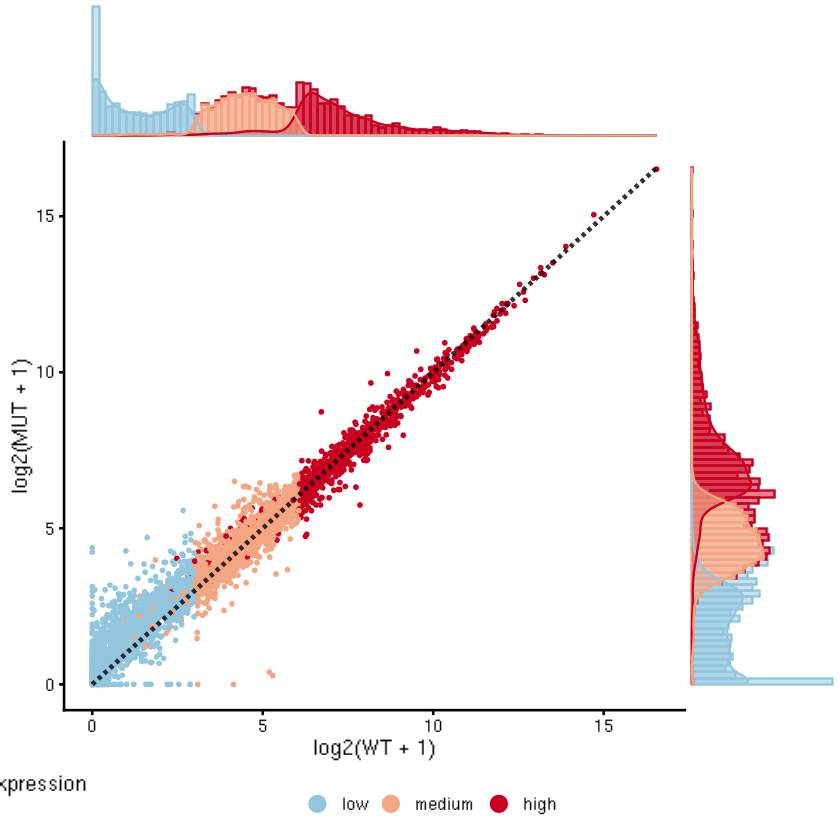

In [83]:
mcol <- rev(c("#ca0020", "#f4a582", "#92c5de"))
names(mcol) <- levels(tpm_ave$class)
intercept = 0
slope = 1

reg_fun <- function(x) intercept + slope * x

p<- tpm_ave %>% 
    ggplot(aes(x  = log2(WT+1), y = log2(MUT+1))) +
    geom_point(aes(color = class), size = 0.5) +
    stat_function(fun = reg_fun, color = "black", linetype = "dashed", linewidth = 1, alpha = 0.8) +
    scale_color_manual(values = mcol) +
    labs(color = "Expression") +
    theme(legend.position = "bottom", legend.background = element_blank(), 
          legend.title = element_text(hjust = 40, vjust = 2, size = 12)) +
    guides(color = guide_legend(override.aes = list(size = 4)))

p2<- ggMarginal(p, groupColour = TRUE, groupFill = TRUE, type = "densigram", binwidth = 0.2, size =4)
p2
ggsave('../figures/Figure1B_total_rna_gene_expression_class.pdf', p2, width = 4, height = 4)

## Figure 1E

In [58]:
diff_nuc<- read.table(file = '../data/5_chromatin_diff_chrom_results.tsv', sep = '\t', header = T, row.names = 1)

In [61]:
mcolors <- polychrome()[c(7, 10, 8, 6, 15)]
names(mcolors) <- c('fully-accessible', 'co-accessible', 'promoter-accessible', 'intragenic-accessible', 'fully-nucleosomal')
mcolors_withsig = c(mcolors, "gray")
names(mcolors_withsig)<- c(names(mcolors), "Not sig")

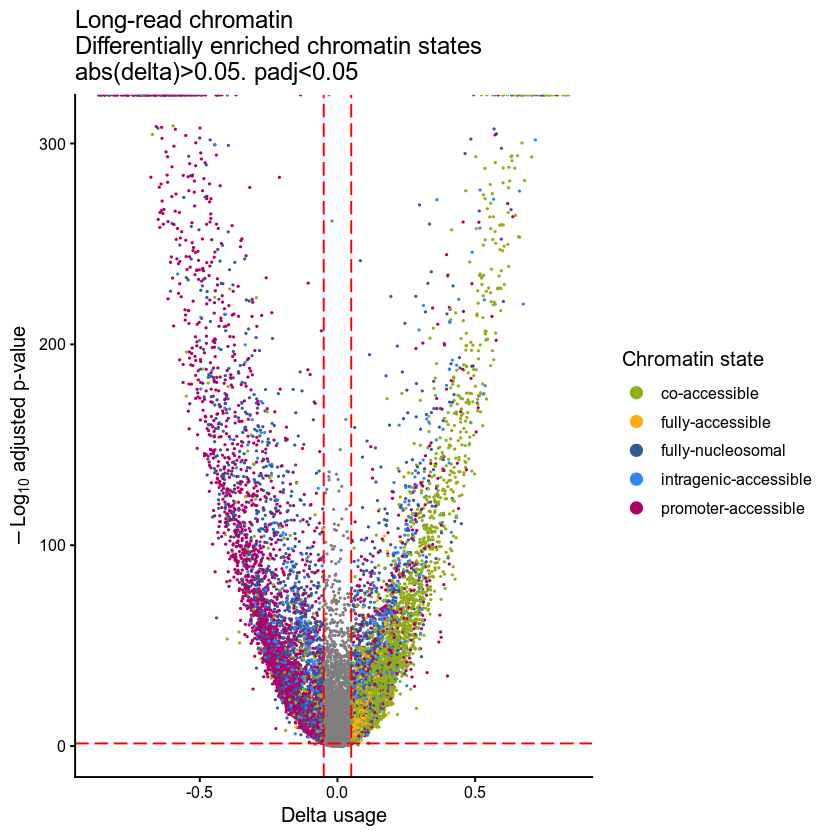

In [67]:
delta_cutoff = 0.05
diff_nuc %>% 
    ggplot(aes(x = delta, y = -log10(pval_adj))) +
    geom_point(aes(color = type), size = 0.2) +
    labs(x = expression("Delta usage"),y = expression(-Log[10] * " adjusted p-value"), 
         title = "Long-read chromatin\nDifferentially enriched chromatin states\nabs(delta)>0.05. padj<0.05", 
         color = "Chromatin state") +
    geom_vline(xintercept = delta_cutoff, color = 'red', linetype = "longdash") +
    geom_vline(xintercept = -delta_cutoff, color = 'red', linetype = "longdash") +
    geom_hline(yintercept = -log10(0.05), color = 'red', linetype = "longdash") +
    scale_color_manual(values = mcolors_withsig) +
    guides(color = guide_legend(override.aes = list(size = 3)))

ggsave("../figures/Figure1E_chrom_state_volcano.pdf",  width = 6, height = 3)

## Figure1F

In [181]:
chrom_delta = read.table(file = "../data/5_chromatin_delta_usage_per_gene", sep = "\t", header = T, check.names = FALSE)

In [182]:
chrom_level = c('promoter-accessible', 'intragenic-accessible', 'co-accessible', 'fully-nucleosomal', 'fully-accessible')

Joining with `by = join_by(class)`


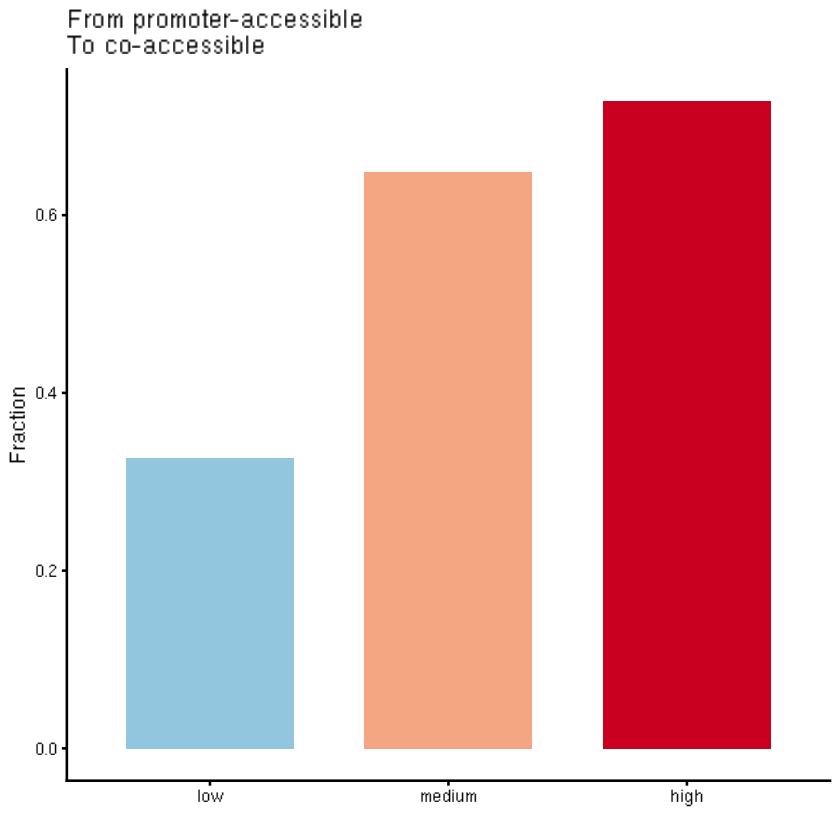

In [183]:
down_state =  "promoter-accessible"
up_state = "co-accessible"
dominance_threshold = 0.5
res = find_shifting_genes(chrom_delta, down_state, up_state, 
                          chrom_level  = chrom_level)
res
ggsave('../figures/Figure1F_find_shifting_genes_from_promoter-accessible_to_co-accessible.pdf', res, width = 5, height = 4)

In [191]:
down_state =  "promoter-accessible"
up_state = "intragenic-accessible"
dominance_threshold = 0.5
res1 = find_shifting_genes(chrom_delta, down_state, up_state, chrom_level  = chrom_level)
ggsave('../figures/Figure1F_find_shifting_genes_from_promoter-accessible_to_intragenic-accessible.pdf', res1, width = 3, height = 4)

down_state =  "fully-nucleosomal"
up_state = "intragenic-accessible"
dominance_threshold = 0.5
res2 = find_shifting_genes(chrom_delta, down_state, up_state, chrom_level  = chrom_level)

ggsave('../figures/Figure1F_find_shifting_genes_from_fully-nucleosomal_to_intragenic-accessible.pdf', res2, width = 3, height = 4)

p1<- wrap_plots(c(res1, res2), ncol = 2)
ggsave('../figures/Figure1F_find_shifting_genes_from_to_intragenic-accessible.pdf', p1, width = 6, height = 4)

Joining with `by = join_by(class)`
Joining with `by = join_by(class)`


In [192]:
down_state =  "fully-nucleosomal"
up_state = "promoter-accessible"
dominance_threshold = 0.5
res1 = find_shifting_genes(chrom_delta, down_state, up_state, 
                          chrom_level  = chrom_level)
ggsave('../figures/Figure1F_find_shifting_genes_from_fully-nucleosomal_to_promoter-accessible.pdf', res1, width = 3, height = 4)

down_state = "promoter-accessible"
up_state =  "fully-nucleosomal"
dominance_threshold = 0.5
res2 = find_shifting_genes(chrom_delta, down_state, up_state, 
                          chrom_level  = chrom_level)
ggsave('../figures/Figure1F_find_shifting_genes_from_promoter-accessible_to_fully-nucleosomal.pdf', res2, width = 3, height = 4)

p1<- wrap_plots(c(res1, res2), ncol = 2)
ggsave('../figures/Figure1F_find_shifting_genes_from_to_fully-nucleosomal.pdf', p1, width = 6, height = 4)

Joining with `by = join_by(class)`
Joining with `by = join_by(class)`


pdf 
  2

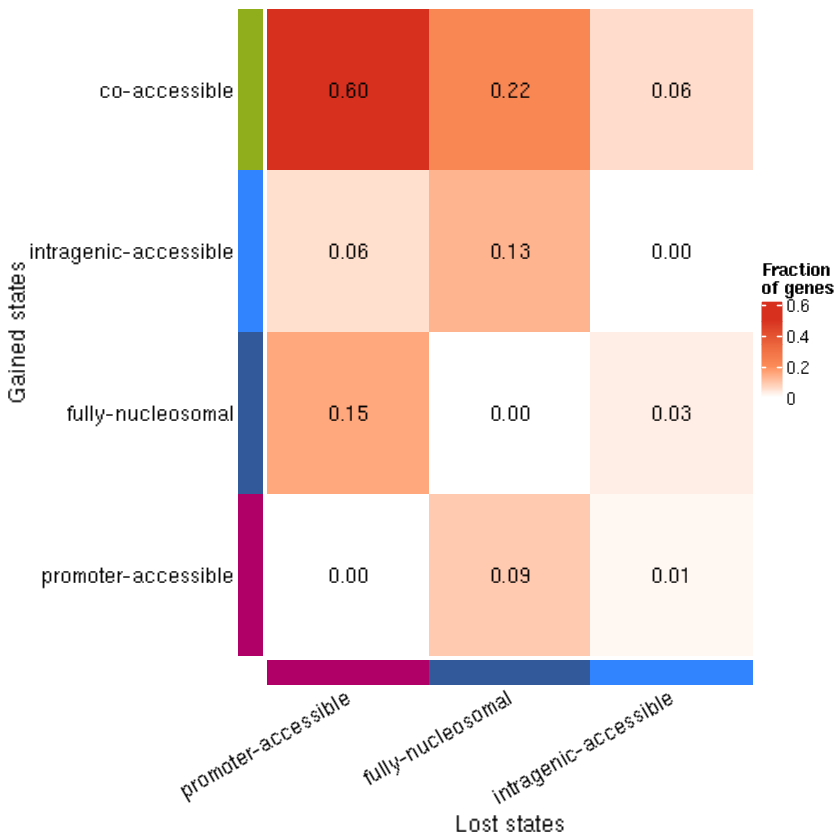

In [193]:
mcolors <- polychrome()[c(7, 10, 8, 6, 15)]
names(mcolors) <- c("fully-accessible", "co-accessible", "promoter-accessible",
                     "intragenic-accessible", "fully-nucleosomal")



gained_states <- c("co-accessible", "intragenic-accessible", "fully-nucleosomal", "promoter-accessible")
lost_states   <- c("promoter-accessible", "fully-nucleosomal", "intragenic-accessible")

mcolors = mcolors[unique(sort(c(gained_states, lost_states)))]

flux_mat <- matrix(0, nrow = length(chrom_level), ncol = length(chrom_level),
                   dimnames = list(gained = chrom_level, lost = chrom_level))

for (i in seq_len(nrow(chrom_delta))) {
  row_vals <- as.numeric(chrom_delta[i, chrom_level])
  names(row_vals) <- chrom_level
  g_states <- names(row_vals[row_vals > 0.01])
  l_states <- names(row_vals[row_vals < -0.01])
  for (g in g_states) for (l in l_states) {
    flux_mat[g, l] <- flux_mat[g, l] + 1
  }
}

flux_frac <- flux_mat / nrow(chrom_delta)

flux_sub <- flux_frac[gained_states, lost_states, drop = FALSE]

row_ha <- rowAnnotation(
  State = gained_states,
  col   = list(State = mcolors),
  show_annotation_name = FALSE,
  show_legend = FALSE
)

col_ha <- HeatmapAnnotation(
  State = lost_states,
  col   = list(State = mcolors),
  show_annotation_name = FALSE,
  show_legend = FALSE
)

ht <- Heatmap(flux_sub,
        name = "Fraction\nof genes",
        cluster_rows = FALSE,
        cluster_columns = FALSE,
        col = colorRamp2(c(0, 0.2, 0.5), c("white", "#fc8d59", "#d7301f")),
        row_title = "Gained states",
        column_title = "Lost states",
        column_title_side = "bottom",
        column_names_rot = 30,
        show_row_dend = FALSE,
        show_column_dend = FALSE,
        show_row_names = TRUE,
        show_column_names = TRUE,
        column_names_side = "bottom",
        row_names_side = "left",
        left_annotation = row_ha,
        top_annotation = NULL,
        bottom_annotation = col_ha,
        cell_fun = function(j, i, x, y, w, h, fill) {
          grid.text(sprintf("%.2f", flux_sub[i, j]), x, y, gp = gpar(fontsize = 12))
        })

lgd_chrom <- Legend(
  title     = "Chromatin state",
  labels    = names(mcolors),
  legend_gp = gpar(fill = mcolors)
)

pdf("../figures/Figure1G_gain_and_loss_chromatin_states.pdf", width = 6, height = 4)
draw(ht, heatmap_legend_side = "right")
dev.off()

# draw(ht, annotation_legend_list = list(lgd_chrom), heatmap_legend_side = "right")
draw(ht, heatmap_legend_side = "right")